In [1]:
import numpy as np
import librosa
import audioflux as af
import soundfile as sf
import matplotlib.pyplot as plt
import sklearn
import scipy
import writing
import analysis

c:\Users\hippo\miniconda3\envs\fieldmusic\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


None
..\..\corpus\metro_sample_1\input.wav
True


In [6]:
input_file = "..\..\corpus\\guitar_sample_2\input.wav"
output_dir = "..\..\corpus\\guitar_sample_2"

sr=48000
grain_duration = 0.1 # in s

y, sr = af.read(input_file, samplate=sr) # sr is 48kHz

grain_size = int(grain_duration * sr)
n_grains_in_source = int(len(y) // grain_size)
grains = [i*grain_size for i in range(n_grains_in_source)]

# since BFT is based on the FFT, the number of bins needs to be half that of a power of 2
bft_obj = af.BFT(num=2049, samplate=sr, radix2_exp=12, slide_length=grain_size,
               data_type=af.type.SpectralDataType.MAG,
               scale_type=af.type.SpectralFilterBankScaleType.LINEAR)
spec_arr = bft_obj.bft(y)
spec_arr = np.abs(spec_arr)
spectral_obj = af.Spectral(num=bft_obj.num,
                           fre_band_arr=bft_obj.get_fre_band_arr())
n_time = spec_arr.shape[-1]  
spectral_obj.set_time_length(n_time)
rms_arr = spectral_obj.rms(spec_arr)
flatness_arr = spectral_obj.flatness(spec_arr)


c:\Users\hippo\miniconda3\envs\fieldmusic\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


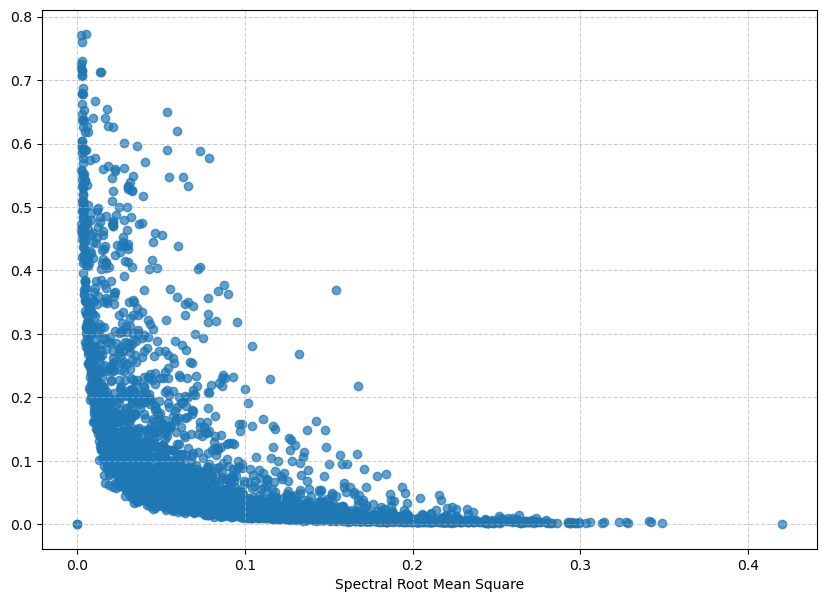

In [ ]:
n_clusters = 4
x = np.array([[i, j] for i, j in zip(rms_arr, flatness_arr)])
kmeans = sklearn.cluster.KMeans(n_clusters=n_clusters, n_init=1, random_state=0).fit(x)
plt.figure(figsize=(10, 7))
plt.scatter(flatness_arr, rms_arr, alpha=0.7)
# plt.ylabel()
plt.xlabel("Spectral Root Mean Square")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



dict_clusters = {}
for idx, lab in enumerate(kmeans.labels_):
    dict_clusters[lab] = dict_clusters.get(lab, [])
    dict_clusters[lab].append(idx)

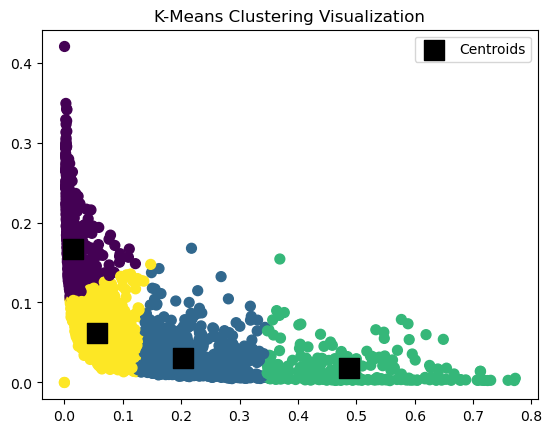

In [8]:
plt.scatter(x[:, 0], x[:, 1], c=kmeans.labels_, cmap='viridis', s=50)

# Plotting the centroids as large red stars
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, marker=',', label='Centroids')

plt.title("K-Means Clustering Visualization")
plt.legend()
plt.show()

### Define the matrix
See logs in notebook_logs.md


In [13]:
# TPM
# tpm = [
#     [0.1, 0.15, 0.15, 0.1],
#     [0.1, 0.4, 0.4, 0.1],
#     [0.1, 0.4, 0.4, 0.1],
#     [0.3, 0, 0, 0.7]
#     ]

# tpm = [
#     [0.6, 0.15, 0.15, 0.1],
#     [0.1, 0.4, 0.4, 0.1],
#     [0, 0.1, 0.3, 0.6],
#     [0, 0, 0.1, 0.9]
#     ]

tpm = [
    [0.6, 0.15, 0.15, 0.1],
    [0.1, 0.1, 0, 0.8],
    [0.9, 0.05, 0.05, 0],
    [0.9, 0, 0.1, 0]
    ]

In [17]:
window = np.hanning
output_buffer = np.array([]) 
curr_state = 3
n_iterations = 300//2
seed = 101
s = np.random.seed(seed)

for i in range(n_iterations):

    next_label = np.random.choice(range(n_clusters), p=tpm[curr_state])
    grain_idx = np.random.choice(dict_clusters[next_label]) # uniform sampling from a cluster
    grain_y_idx = grains[grain_idx]
    grain = y[grain_y_idx:grain_y_idx+grain_size]
    grain = grain * np.hanning(grain_size)
    output_buffer = np.concatenate([output_buffer, grain])
    curr_label = next_label
# output_buffer / np.max(np.abs(output_buffer))

In [18]:
try:
    window_name = window.__name__
except AttributeError as e:
    window_name = "None"
parametre_dict = {
    "random_seed" : seed,
    "sample_rate" : sr,
    "input_file" : input_file, 
    "n_clusters" : n_clusters,
    # "densities" : densities,
    # "grain_sizes" : sizes,
    "n_iterations" : n_iterations,
    # "stereo_shifts" : stereo_shifting,
    # "delta_t" : delta_t,
    # "max_grains" : max_grains,
    # "num_chans" : num_chans,
    # "init_states_densities_sizes" : [int(i) for i in init_poisson_states],
    # "init_states_grain_cluster" : [int(i) for i in init_cluster_states],
    # "git_hash" : TODO: add git hash,
    "project" : "markov_gs",
    # "poisson_change_rates" : int(density_change_rate),
    "window" : window_name,
    "gs_method": "base_concatenative_synthesis_1",
    "transition_probability_matrix": tpm
}

writing.save_output_data(output_buffer, sr, parametre_dict, output_dir)

In [13]:
import os
os.path.exists("..\\..\\corpus\\guitar_sample_1\\output\\20260506_650909.wav")

True

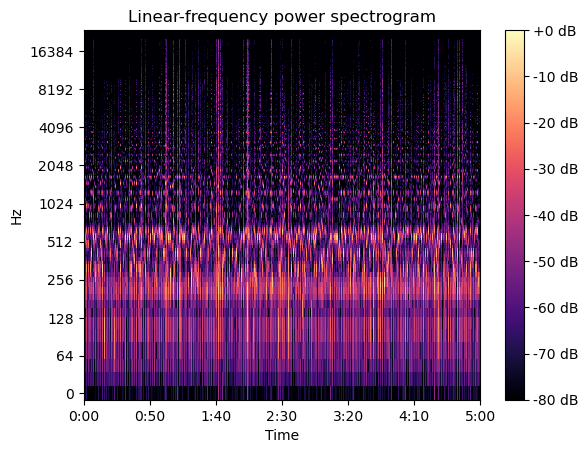

In [17]:
y, sr = librosa.load(path="..\\..\\corpus\\guitar_sample_1\\output\\20260506_4723f6.wav", sr=48000)

analysis.get_spectrogram(y, 'log', 'time', sr)

In [2]:
y, sr = librosa.load(path="..\\..\\corpus\\guitar_sample_1\\output\\20260506_143dd5.wav", sr=48000)
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
R = librosa.segment.recurrence_matrix(D, metric='cosine')


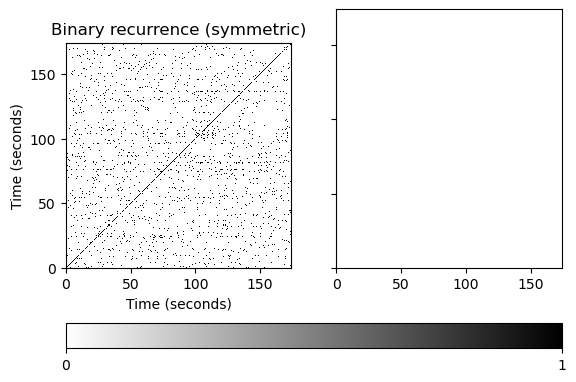

In [5]:
import matplotlib.pyplot as plt
hop_length = 1024

fig, ax = plt.subplots(ncols=2, sharex=True, sharey=True)
imgsim = librosa.display.specshow(R, x_axis='s', y_axis='s',
                         hop_length=hop_length, ax=ax[0])
ax[0].set(title='Binary recurrence (symmetric)')
fig.colorbar(imgsim, ax=ax, orientation='horizontal', ticks=[0, 1])
# fig.colorbar(imgaff, ax=ax[1], orientation='horizontal')

In [25]:
obj = analysis.AnalysisObject(dir=output_dir, sr=sr)
obj.load_soundfile()

..\..\corpus\guitar_sample_2\input.wav
